## Telecom Customer Churn

### Business goal:
####  Identify customers who will leave so the company can stop revenue loss.

### Customer Churn (Yes/No)
#### This is Binary Classification

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from xgboost import XGBClassifier

In [5]:
data = pd.read_csv("CustomerChurn.csv")

In [6]:
data .head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [8]:
data.isnull().sum()

LoyaltyID            0
Customer ID          0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [10]:
data = data.drop(columns=["LoyaltyID","Customer ID"])

In [11]:
data.shape

(7043, 19)

In [12]:
data.head()

,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
data["Payment Method"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [14]:
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce')

In [15]:
data['Total Charges'].fillna(data['Total Charges'].median(), inplace=True)
data.dropna(subset=['Total Charges'], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_14592\323111689.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Total Charges'].fillna(data['Total Charges'].median(), inplace=True)


In [16]:
data.isnull().sum()

Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

### Define features

In [18]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

x_train , x_test , y_train , y_test = train_test_split(
    X, y ,test_size = 0.2,stratify=y,random_state=42
)

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

### Preprocessing pipeline

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ("num",StandardScaler(),numeric_features),
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
])

### Train a Model 

In [22]:
clf = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",LogisticRegression(class_weight='balanced'))
    ]
)

clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### XGBOOSTCLASSIFIRE

In [24]:
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

In [25]:
y = data["Churn"]
X = data.drop(columns=["Churn"])

In [26]:
data["Churn"].unique()

array([0, 1], dtype=int64)

### Handle Imbalanced Data for XGBoost

XGBoost is penalize errors on the minority class more heavily.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [32]:
neg = sum(y == 0)
pos = sum(y == 1)

scale_pos_weight = neg / pos
print(scale_pos_weight)


2.7683253076511503


In [33]:
xgclf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", XGBClassifier(scale_pos_weight=scale_pos_weight,
                                n_estimators=200,
                                learning_rate=0.02,
                                max_depth=4,
                                subsample=0.8,
                                colsample_bytree=0.7,
                               eval_metric='logloss',
                                random_state=42)
        )
    ]
)

xgclf.fit(X_train, y_train)

y_pred = xgclf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



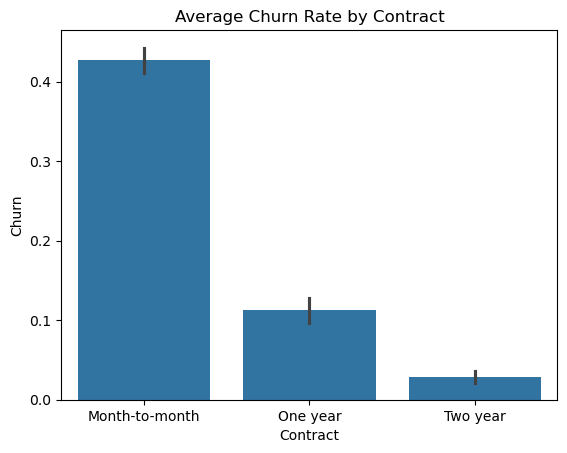

In [34]:
sns.barplot(
    x="Contract",
    y="Churn",
    data=data
)
plt.title("Average Churn Rate by Contract")
plt.show()


ROC-AUC: 0.8479772146012555


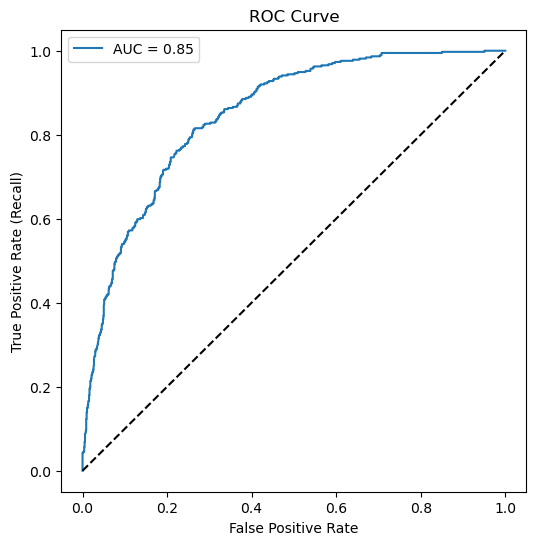

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predicted probabilities
y_proba = xgclf.predict_proba(X_test)[:, 1]

# ROC-AUC score
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

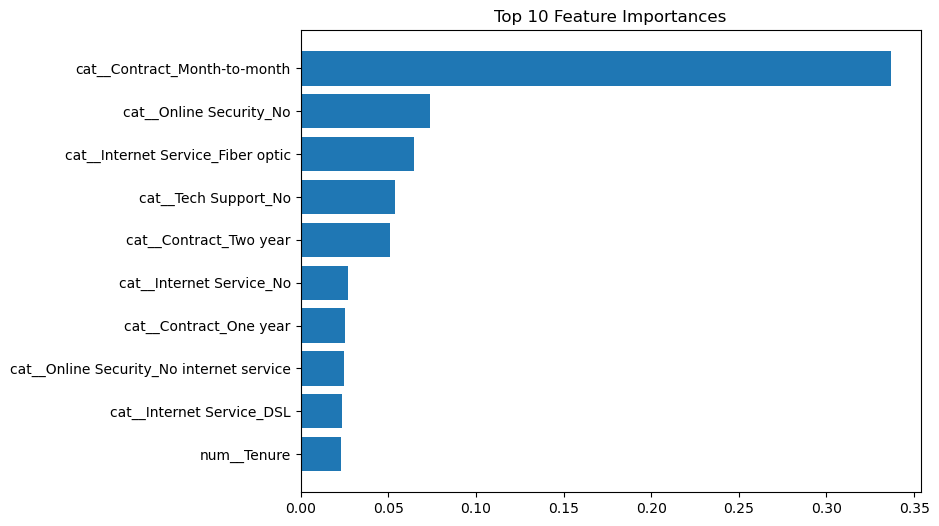

In [36]:
import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = xgclf.named_steps['preprocess'].get_feature_names_out()

# Get importance values
importances = xgclf.named_steps['model'].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.show()


              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



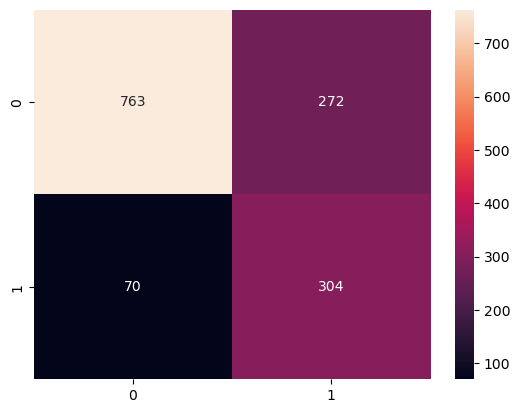

In [37]:
y_pred = xgclf.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.show()

In [38]:
from lifelines import KaplanMeierFitter

In [39]:
data["Churn_event"] = data["Churn"]

In [40]:
data[["Tenure", "Churn"]].isnull().sum()

Tenure    0
Churn     0
dtype: int64

### Overall Customer Survival

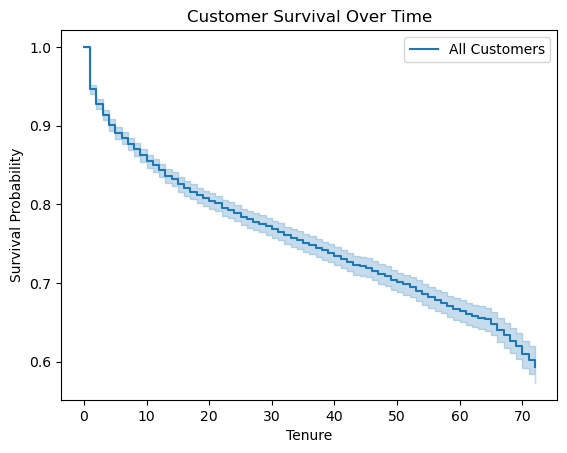

In [42]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=data["Tenure"],
    event_observed=data["Churn"],
    label="All Customers"
)

kmf.plot()
plt.title("Customer Survival Over Time")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.show()

“This shows how customer survival decreases over time.
Most churn happens in the early months, which highlights the importance of early engagement.”

### Survival by Contract Type

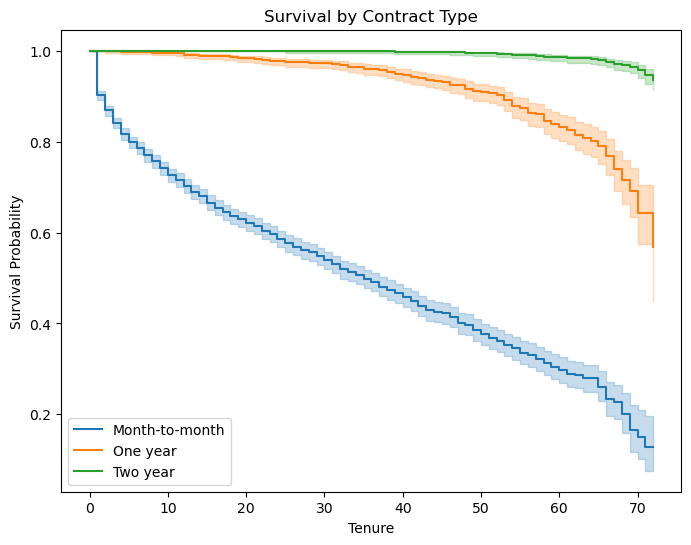

In [45]:
plt.figure(figsize=(8,6))
kmf = KaplanMeierFitter()

for contract in data["Contract"].unique():
    mask = data["Contract"] == contract
    
    kmf.fit(
        data.loc[mask, "Tenure"],
        data.loc[mask, "Churn_event"],
        label=contract
    )
    kmf.plot_survival_function()

plt.title("Survival by Contract Type")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


“Month-to-month customers churn much earlier than customers on one-year or two-year contracts.
This suggests long-term contracts help improve retention

### Survival by Payment Method

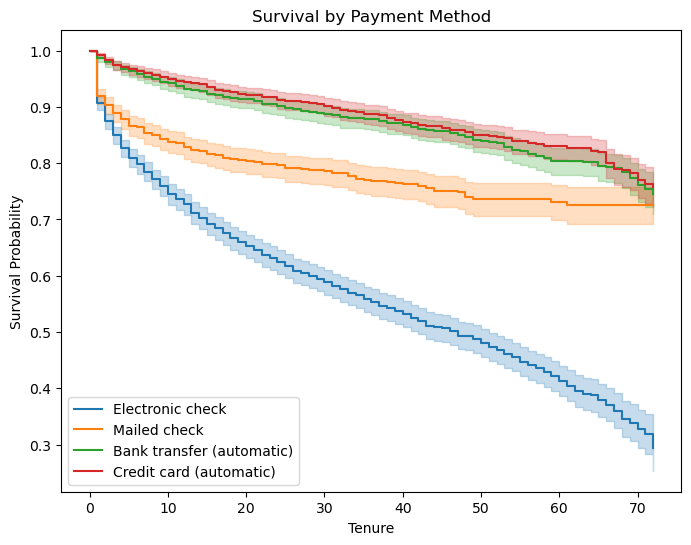

In [48]:
plt.figure(figsize=(8,6))
kmf = KaplanMeierFitter()

for method in data["Payment Method"].unique():
    mask = data["Payment Method"] == method
    
    kmf.fit(
        data.loc[mask, "Tenure"],
        data.loc[mask, "Churn_event"],
        label=method
    )
    kmf.plot_survival_function()

plt.title("Survival by Payment Method")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()


Customers using electronic check tend to churn faster than those using automatic payment methods.
This may be due to payment friction or missed payments.”

### Survival by Internet Service Type

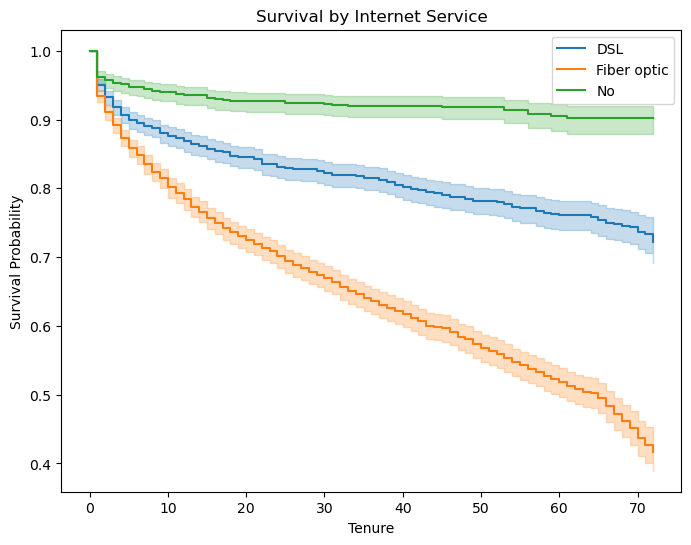

In [51]:
plt.figure(figsize=(8,6))
kmf = KaplanMeierFitter()

for service in data["Internet Service"].unique():
    mask = data["Internet Service"] == service
    
    kmf.fit(
        data.loc[mask, "Tenure"],
        data.loc[mask, "Churn_event"],
        label=service
    )
    kmf.plot_survival_function()

plt.title("Survival by Internet Service")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

“Fiber optic customers show higher churn compared to other services, possibly due to higher cost or service expectations.”

### Survival by Monthly Charges (Binned)

In [54]:
data["MonthlyCharges_group"] = pd.qcut(
    data["Monthly Charges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

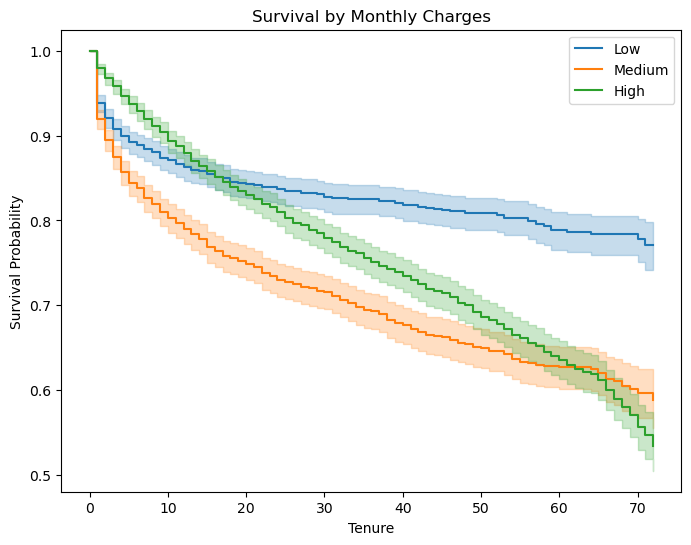

In [55]:
plt.figure(figsize=(8,6))
kmf = KaplanMeierFitter()

for grp in data["MonthlyCharges_group"].unique():
    mask = data["MonthlyCharges_group"] == grp
    
    kmf.fit(
        data.loc[mask, "Tenure"],
        data.loc[mask, "Churn_event"],
        label=grp
    )
    kmf.plot_survival_function()

plt.title("Survival by Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

Customers with higher monthly charges tend to churn faster, indicating price sensitivity or perceived value issues.”

In [57]:
import joblib
joblib.dump(xgclf,"costomer_churn_pipline.pkl")

['costomer_churn_pipline.pkl']

In [58]:
data.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn', 'Churn_event',
       'MonthlyCharges_group'],
      dtype='object')

### For LTV: (Life time Value for costomers)

In [128]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
import pickle

In [102]:
df = pd.read_csv("CustomerChurn.csv")

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoyaltyID          7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure             7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [108]:
df = df.drop(columns=["LoyaltyID","Customer ID"])

In [112]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [114]:
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
df.dropna(subset=['Total Charges'], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_14592\868805959.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


In [116]:
df['Monthly Charges'] = pd.to_numeric(df['Monthly Charges'], errors='coerce')

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Senior Citizen     7043 non-null   object 
 1   Partner            7043 non-null   object 
 2   Dependents         7043 non-null   object 
 3   Tenure             7043 non-null   int64  
 4   Phone Service      7043 non-null   object 
 5   Multiple Lines     7043 non-null   object 
 6   Internet Service   7043 non-null   object 
 7   Online Security    7043 non-null   object 
 8   Online Backup      7043 non-null   object 
 9   Device Protection  7043 non-null   object 
 10  Tech Support       7043 non-null   object 
 11  Streaming TV       7043 non-null   object 
 12  Streaming Movies   7043 non-null   object 
 13  Contract           7043 non-null   object 
 14  Paperless Billing  7043 non-null   object 
 15  Payment Method     7043 non-null   object 
 16  Monthly Charges    7043 

In [134]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [173]:
x = df.drop(['Churn', 'Total Charges',"Tenure"], axis=1) 
y_ltv = df['Total Charges']

In [175]:
x_train, x_test,y_train,y_test = train_test_split(x,y_ltv,test_size=0.2,random_state=42)

In [177]:
categorical_features = x.select_dtypes(include="object").columns.tolist()
numeric_features = x.select_dtypes(exclude="object").columns.tolist()

In [179]:
preprocessor = ColumnTransformer(transformers=[

    ("num",StandardScaler(),numeric_features),

    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)

])


In [181]:
ltv_model = Pipeline(
    steps=[

        ("preprocess",preprocessor),

        ("model",XGBRegressor(n_estimators=100, learning_rate=0.05,max_depth=5))

    ]
)

In [183]:
ltv_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [185]:
predictions = ltv_model.predict(X_test)
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions):.2f}")
print(f"R2 Score: {r2_score(y_test, predictions):.2f}")

Mean Absolute Error: $727.91
R2 Score: 0.80


###  Cost-Benefit Analysis

In [216]:
# 1. Create a version of X_test that includes 'Total Charges' for the Churn Model
# (Assuming  y_test_ltv contains the actual Total Charges)
X_test_for_churn = X_test.copy()
X_test_for_churn['Total Charges'] = y_test 

# 2. Now get the predictions separately using the correct columns
predictions_churn = xgclf.predict(X_test_for_churn) # Needs Total Charges
predictions_ltv = ltv_model.predict(X_test)             # Does NOT have Total Charges

# 3. Combine them into a table for viewing
test_results = X_test.copy()
test_results['Predicted_LTV'] = predictions_ltv
test_results['Predicted_Churn'] = predictions_churn

# 4. Filter for Low Value (< 500) and High Risk (Churn == 1)
non_profit_list = test_results[(test_results['Predicted_LTV'] < 500) & (test_results['Predicted_Churn'] == 1)]
print(f"Success! Found {len(non_profit_list)} non-profitable customers.")

Success! Found 123 non-profitable customers.


In [218]:
pickle.dump(ltv_model, open('ltv_model.pkl', 'wb'))